#### Looking deeper under the hood of the neural network

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
names = open('names.txt', 'r').read().splitlines()
print(f"total names in dataset: {len(names)}")

total names in dataset: 32033


In [3]:
# build character vocabulary and mapping
chars = sorted(list(set(''.join(names))))
ctoi = {c:i+1 for i,c in enumerate(chars)}
ctoi['.'] = 0
itoc = {i:c for c, i in ctoi.items()}
vocab_size = len(itoc)
print(f"characters: {vocab_size}")

characters: 27


In [32]:
# build the dataset
block_size = 3 # context length

def build_dataset(names):
    X, Y = [], []

    for n in names:
        context = [0] * block_size
        for ch in n + '.':
            ix = ctoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(1994)
random.shuffle(names)
n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

print("Xtrn, Ytrn = 80%")
Xtrn, Ytrn = build_dataset(names[:n1])
print("Xdev, Ydev = 10%")
Xdev, Ydev = build_dataset(names[n1:n2])
print("Xtst, Ytst = 10%")
Xtst, Ytst = build_dataset(names[n2:])

Xtrn, Ytrn = 80%
torch.Size([182560, 3]) torch.Size([182560])
Xdev, Ydev = 10%
torch.Size([22778, 3]) torch.Size([22778])
Xtst, Ytst = 10%
torch.Size([22808, 3]) torch.Size([22808])


In [5]:
# initializing the model
n_embedding = 10 # size of the embedding dimension
n_hidden = 200 # number of neurons in the hidden layer
g = torch.Generator().manual_seed(1994) # generator for reproducibility

C = torch.randn((vocab_size, n_embedding),            generator=g)
W1 = torch.randn((n_embedding*block_size, n_hidden),  generator=g)
b1 = torch.randn(n_hidden,                            generator=g)
W2 = torch.randn((n_hidden, vocab_size),              generator=g)
b2 = torch.randn(vocab_size,                          generator=g) 

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True
    
print(f"number of parameters = {sum(p.nelement() for p in parameters)}")

number of parameters = 11897


In [6]:
# training the model
batch_size = 32
steps = 200000
loss_i = []

print(f"  epoch  loss")
for i in range(steps):
    # batch the training data to optimize
    ix = torch.randint(0, Xtrn.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtrn[ix], Ytrn[ix] # batch X, Y
    
    # forward pass
    emb = C[Xb] # embed the input batch characters
    emb_cat = emb.view(emb.shape[0], -1) # concatenate embeddings
    h_pre_act = emb_cat @ W1 + b1 # linear hidden layer
    h = torch.tanh(h_pre_act) # nonlinear hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    lr = 0.1 if i < 100000 else 0.01 # temper learning rate with increasing epochs
    for p in parameters:
        p.data -= lr * p.grad

    # track statistics
    if i % 10000 == 0:
        print(f"{i:7d}: {loss:4f}")
    loss_i.append(loss.log10().item())

print(f"{i:7d}: {loss:4f}")

  epoch  loss
      0: 19.401640
  10000: 2.701766
  20000: 2.382249
  30000: 2.411464
  40000: 3.282574
  50000: 2.061475
  60000: 2.266419
  70000: 2.441854
  80000: 2.183485
  90000: 2.277020
 100000: 2.527660
 110000: 2.123291
 120000: 2.405596
 130000: 2.056341
 140000: 1.858463
 150000: 1.761970
 160000: 2.590912
 170000: 1.853484
 180000: 2.086316
 190000: 2.037588
 199999: 2.431010


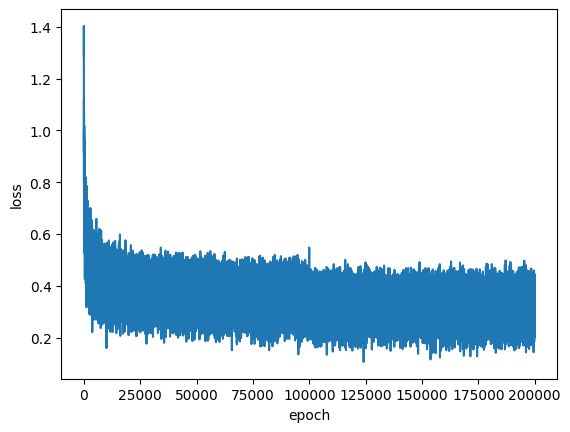

In [7]:
# plotting loss
plt.plot(loss_i)
plt.ylabel("loss");
plt.xlabel("epoch");

In [8]:
# assessing the model for fitness
@torch.no_grad() # decorator which boosts efficiency by bypassing backpropagation circuitry
def split_loss(split):
    x,y = {
        'train': (Xtrn, Ytrn),
        'val':   (Xdev, Ydev),
        'test':  (Xtst, Ytst)
    }[split]
    emb = C[x]
    emb_cat = emb.view(emb.shape[0], -1)
    h = torch.tanh(emb_cat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1204211711883545
val 2.1630280017852783


#### these training results tell us that the MLP is not initialized correctly, its loss at the beginning is much higher than expected
#### the first culprit is the logits
#### the naive likelihood of a character $L_0 = \frac{1}{27}$, thus, the theoretical loss of this untrained character language model $-\log(\frac{1}{27}) ≈ 3.29$
#### the fact that the loss is so much higher is in part due to the model assigning high confidence to incorrect predictions at initialization


In [9]:
# illustrating the point with a simple 4-dimensional example
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
print(f"if the logits <{logits}> are initialized close to 0,\
    \nthe softmax <{probs}> returns a flat probability distribution.\
    \nif e.g., [2] is the correct label, the loss <{loss:4f}> is at its naive theoretical starting point\n")

logits = torch.tensor([0.0, 0.0, 5.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
print(f"if the model initializes high logits <{logits}> to the correct label by chance,\
    \nthe loss <{loss:4f}> is low\n")

logits = torch.tensor([0.0, 0.0, -5.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
print(f"and if the model initializes low logits <{logits}> to the correct label by chance,\
    \nthe loss <{loss:4f}> is high\n")

logits = torch.randn(4)*10
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
print(f"indeed initializing logits randomly <{logits}> tends to generate high loss\
    \nthe loss <{loss:4f}> is high")

if the logits <tensor([0., 0., 0., 0.])> are initialized close to 0,    
the softmax <tensor([0.2500, 0.2500, 0.2500, 0.2500])> returns a flat probability distribution.    
if e.g., [2] is the correct label, the loss <1.386294> is at its naive theoretical starting point

if the model initializes high logits <tensor([0., 0., 5., 0.])> to the correct label by chance,    
the loss <0.020012> is low

and if the model initializes low logits <tensor([ 0.,  0., -5.,  0.])> to the correct label by chance,    
the loss <6.100856> is high

indeed initializing logits randomly <tensor([-11.4054,   7.5748,  -4.3813,  -3.2502])> tends to generate high loss    
the loss <11.956089> is high


In [10]:
# so let's modify the parameter initialization with the goal of driving the starting logits (computed from W2 and b2) to 0

n_embedding = 10 # size of the embedding dimension
n_hidden = 200 # number of neurons in the hidden layer
g = torch.Generator().manual_seed(1994) # generator for reproducibility

C = torch.randn((vocab_size, n_embedding),            generator=g)
W1 = torch.randn((n_embedding*block_size, n_hidden),  generator=g)
b1 = torch.randn(n_hidden,                            generator=g)
W2 = torch.randn((n_hidden, vocab_size),              generator=g) * 0.01
b2 = torch.randn(vocab_size,                          generator=g) * 0

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True
    
print(f"number of parameters = {sum(p.nelement() for p in parameters)}")

number of parameters = 11897


In [11]:
# and retrain the model
batch_size = 32
steps = 200000
loss_i = []

print(f"  epoch  loss")
for i in range(steps):
    # batch the training data to optimize
    ix = torch.randint(0, Xtrn.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtrn[ix], Ytrn[ix] # batch X, Y
    
    # forward pass
    emb = C[Xb] # embed the input batch characters
    emb_cat = emb.view(emb.shape[0], -1) # concatenate embeddings
    z = emb_cat @ W1 + b1 # linear hidden layer
    h = torch.tanh(z) # nonlinear hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    lr = 0.1 if i < 100000 else 0.01 # temper learning rate with increasing epochs
    for p in parameters:
        p.data -= lr * p.grad

    # track statistics
    if i % 10000 == 0:
        print(f"{i:7d}: {loss:4f}")
    loss_i.append(loss.log10().item())

print(f"{i:7d}: {loss:4f}")

  epoch  loss
      0: 3.262614
  10000: 2.672370
  20000: 2.248080
  30000: 2.203357
  40000: 2.625279
  50000: 2.145949
  60000: 1.880151
  70000: 2.247551
  80000: 2.102035
  90000: 2.315717
 100000: 2.347971
 110000: 2.075005
 120000: 2.374530
 130000: 2.016198
 140000: 1.867973
 150000: 1.687480
 160000: 2.504254
 170000: 1.853057
 180000: 2.075428
 190000: 1.855309
 199999: 2.234704


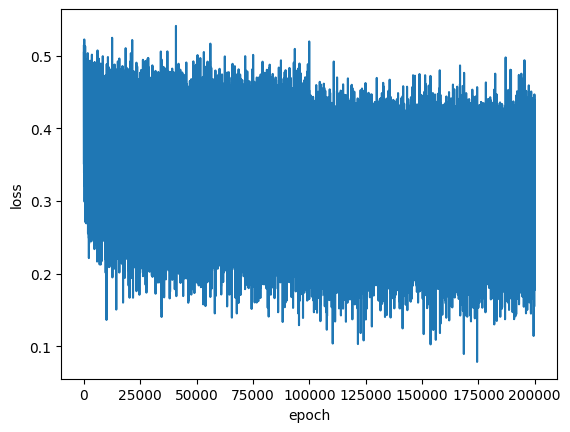

In [12]:
# plotting loss
plt.plot(loss_i)
plt.ylabel("loss");
plt.xlabel("epoch");

In [13]:
# assessing the model for fitness
split_loss('train')
split_loss('val')

train 2.068695545196533
val 2.1278514862060547


#### confidently wrong logits are not the only issue
#### in the activations of the hidden layer $H = \tanh(z)$, where $z = X_{emb} \cdot W_1 + b_1$, there is a bigger problem
#### many of the activations are very close to $1$ or $-1$, in the tail ends of the $tanh$ function
#### since the gradient $= 1-H^2$, as $H \rightarrow -1$ or $1$, the gradient will vanish
#### this halts the learning loop which nudges parameters by the scaled gradient
#### if all of a neuron's incoming activations are -1 or 1, that neuron cannot learn, and is called "dead"

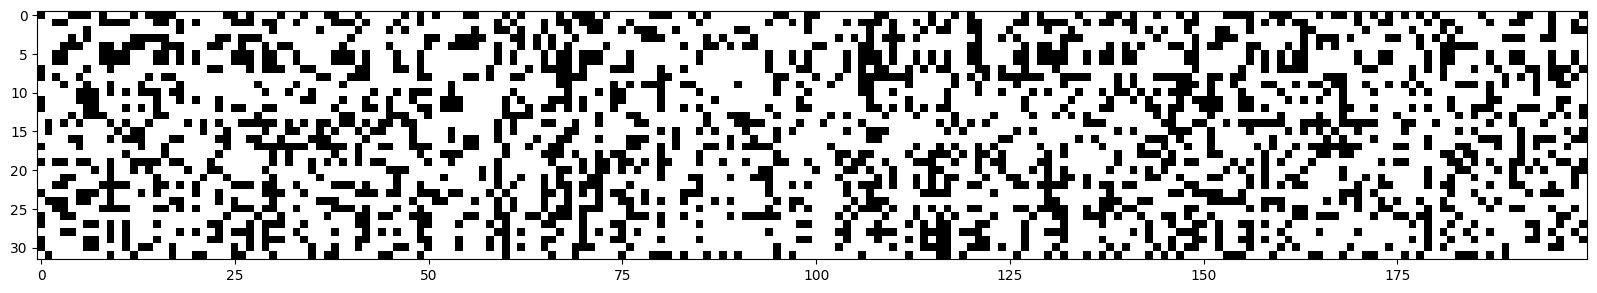

In [14]:
#visualizing all activations which are within 1% of -1 or 1 (white)
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest')

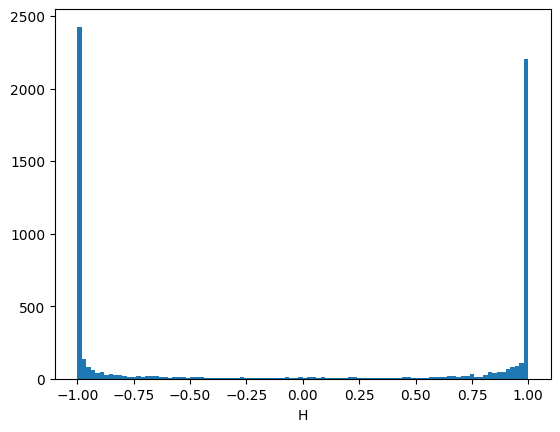

In [15]:
# the histogram of H also shows how most activations are in the tail ends of the tanh, either 1 or -1
plt.hist(h.view(-1).tolist(), 100);
plt.xlabel("H");

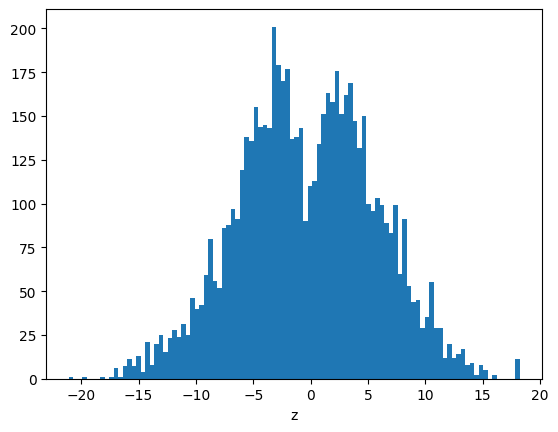

In [16]:
# indeed, this is because the values of z are too extreme
plt.hist(h_pre_act.view(-1).tolist(), 100);
plt.xlabel("z");

In [17]:
# initialize the model again with the goal of tightening the spread of z
n_embedding = 10 # size of the embedding dimension
n_hidden = 200 # number of neurons in the hidden layer
g = torch.Generator().manual_seed(1994) # generator for reproducibility

C = torch.randn((vocab_size, n_embedding),            generator=g)
W1 = torch.randn((n_embedding*block_size, n_hidden),  generator=g) * 0.15 # scaling down the weights to reduce the spread of z
b1 = torch.randn(n_hidden,                            generator=g) * 0.01 # allowing a small bit of entropy in b
W2 = torch.randn((n_hidden, vocab_size),              generator=g) * 0.01
b2 = torch.randn(vocab_size,                          generator=g) * 0

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True
    
print(f"number of parameters = {sum(p.nelement() for p in parameters)}")

number of parameters = 11897


In [18]:
# and check how H and z initialize
batch_size = 32
steps = 200000
loss_i = []

print(f"  epoch  loss")
for i in range(steps):
    # batch the training data to optimize
    ix = torch.randint(0, Xtrn.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtrn[ix], Ytrn[ix] # batch X, Y
    
    # forward pass
    emb = C[Xb] # embed the input batch characters
    emb_cat = emb.view(emb.shape[0], -1) # concatenate embeddings
    z = emb_cat @ W1 + b1 # linear hidden layer
    h = torch.tanh(z) # nonlinear hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    lr = 0.1 if i < 100000 else 0.01 # temper learning rate with increasing epochs
    for p in parameters:
        p.data -= lr * p.grad

    # track statistics
    #if i % 10000 == 0:
        #print(f"{i:7d}: {loss:4f}")
    loss_i.append(loss.log10().item())
    break;

print(f"{i:7d}: {loss:4f}")

  epoch  loss
      0: 3.269520


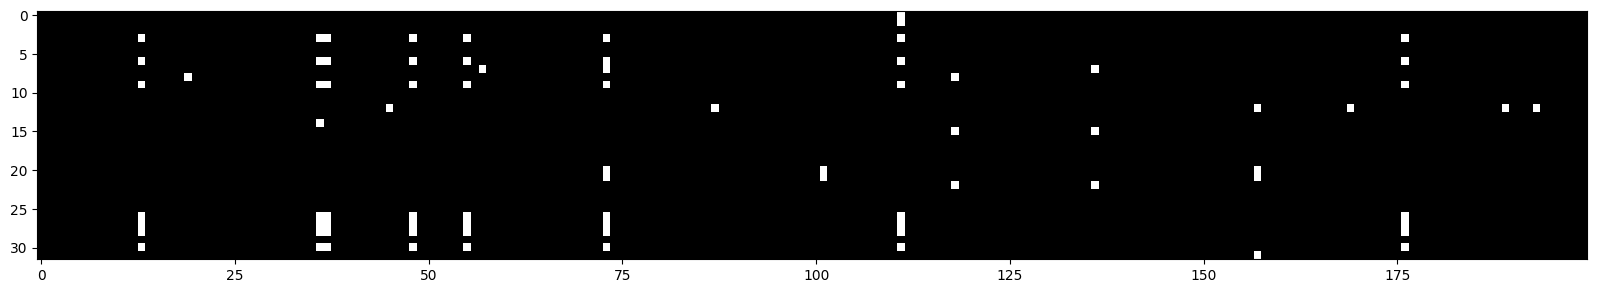

In [19]:
# now the activations are no longer globally impeding the gradient
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest')

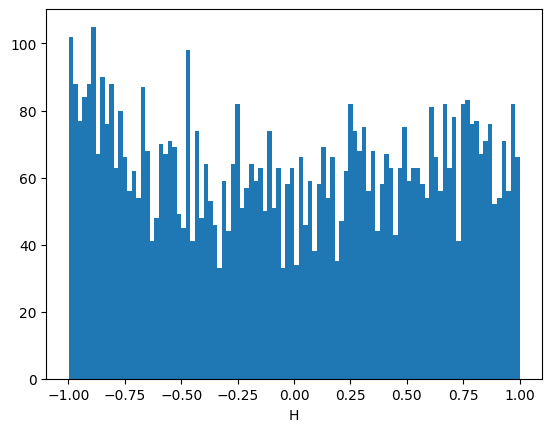

In [20]:
# the histogram is much flatter
plt.hist(h.view(-1).tolist(), 100);
plt.xlabel("H");

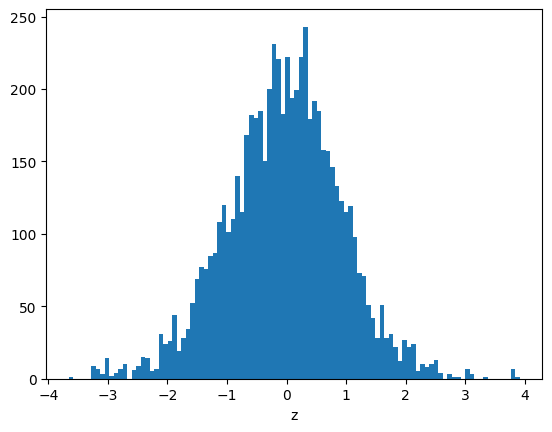

In [21]:
# the values of z have been reined it
plt.hist(z.view(-1).tolist(), 100);
plt.xlabel("z");

#### in practice, the initialization values are not computed heuristically like above, but deterministically
#### successive linear transformations of normally distributed values increases their standard deviation, leading to dead neurons

x mean: 0.007582, x standard deviation: 0.996605
z mean: -0.009638, z standard deviation: 3.121935


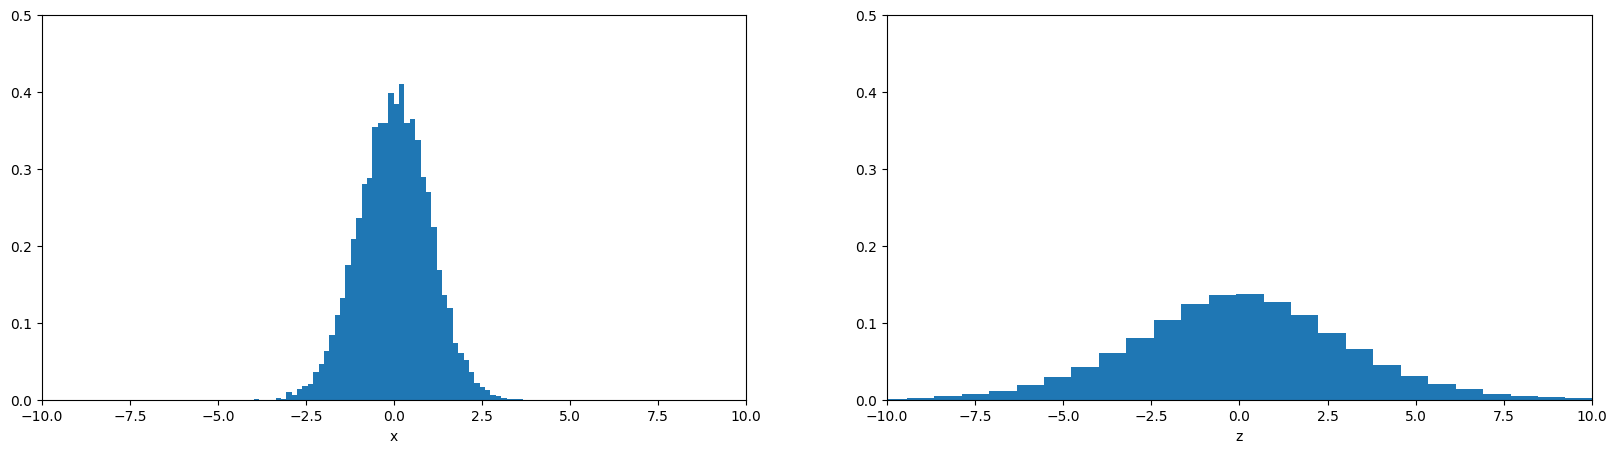

In [22]:
# if x ~ normal distribution, the linear combination z = x • w is normally distributed but with larger variance
x = torch.randn(1000, 10)
w = torch.randn(10, 200)
z = x @ w
print(f"x mean: {x.mean().item():4f}, x standard deviation: {x.std().item():4f}")
print(f"z mean: {z.mean().item():4f}, z standard deviation: {z.std().item():4f}")
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.xlim(-10, 10)
plt.ylim(0, 0.5)
plt.xlabel("x");
plt.subplot(122)
plt.hist(z.view(-1).tolist(), 50, density=True);
plt.xlim(-10, 10)
plt.ylim(0, 0.5)
plt.xlabel("z");

#### if $z=\sum_{i=1}^{n}(w_i*x_i)$, where n = the number of inputs to the neuron (AKA fan-in), then var$(z) = n*$var$(x)*$var$(w)$ (see [He et al. 2015](https://arxiv.org/abs/1502.01852))
#### to make var$(z)=$ var$(x)$, var$(w)=\frac{1}{n}$, i.e., $\sigma=\frac{1}{\sqrt{fan-in}}$
#### this gives us the adjustment factor to $w$

x mean: -0.002751, x standard deviation: 0.996665
z mean: -0.000639, z standard deviation: 0.981924


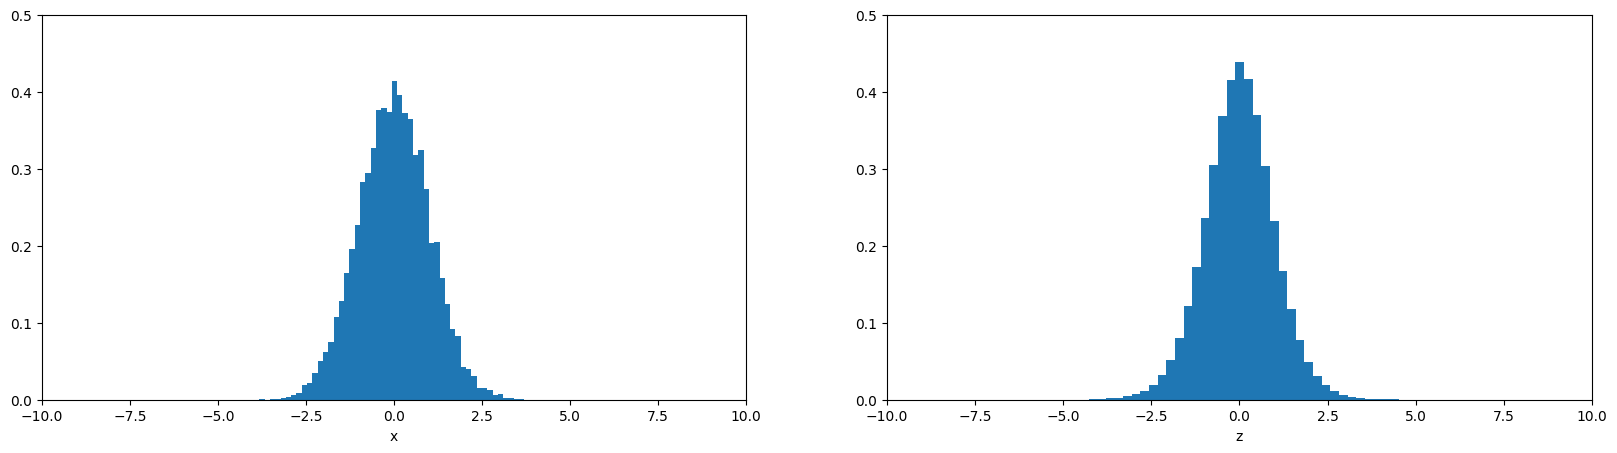

In [23]:
# multiplying w by the adjustment factor 1/√n fixes σ(z)
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
z = x @ w
print(f"x mean: {x.mean().item():4f}, x standard deviation: {x.std().item():4f}")
print(f"z mean: {z.mean().item():4f}, z standard deviation: {z.std().item():4f}")
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.xlim(-10, 10)
plt.ylim(0, 0.5)
plt.xlabel("x");
plt.subplot(122)
plt.hist(z.view(-1).tolist(), 50, density=True);
plt.xlim(-10, 10)
plt.ylim(0, 0.5)
plt.xlabel("z");

#### to compensate for the shape of the tanh nonlinearity, a "gain" of 5/3 is also necessary
#### for an explanation, see [this](https://cs230.stanford.edu/section/4/) Stanford lecture

In [24]:
# computing the normalization factor
gain = 5/3
kaiming = gain/(block_size*n_embedding)**0.5
print(f"normalization factor = {kaiming:4f}")

normalization factor = 0.304290


In [25]:
# initialize the model again with the mathematically precise normalization of z

n_embedding = 10 # size of the embedding dimension
n_hidden = 200 # number of neurons in the hidden layer
g = torch.Generator().manual_seed(1994) # generator for reproducibility

C = torch.randn((vocab_size, n_embedding),            generator=g)
W1 = torch.randn((n_embedding*block_size, n_hidden),  generator=g) * kaiming  # kaiming normalization
b1 = torch.randn(n_hidden,                            generator=g) * 0.01 # allowing a small bit of entropy in b
W2 = torch.randn((n_hidden, vocab_size),              generator=g) * 0.01
b2 = torch.randn(vocab_size,                          generator=g) * 0

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True
    
print(f"number of parameters = {sum(p.nelement() for p in parameters)}")

number of parameters = 11897


In [26]:
# retrain the model and assess performance
batch_size = 32
steps = 200000
loss_i = []

print(f"  epoch  loss")
for i in range(steps):
    # batch the training data to optimize
    ix = torch.randint(0, Xtrn.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtrn[ix], Ytrn[ix] # batch X, Y
    
    # forward pass
    emb = C[Xb] # embed the input batch characters
    emb_cat = emb.view(emb.shape[0], -1) # concatenate embeddings
    z = emb_cat @ W1 + b1 # linear hidden layer
    h = torch.tanh(z) # nonlinear hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    lr = 0.1 if i < 100000 else 0.01 # temper learning rate with increasing epochs
    for p in parameters:
        p.data -= lr * p.grad

    # track statistics
    if i % 10000 == 0:
        print(f"{i:7d}: {loss:4f}")
    loss_i.append(loss.log10().item())

print(f"{i:7d}: {loss:4f}")

  epoch  loss
      0: 3.264387
  10000: 2.602141
  20000: 2.259862
  30000: 2.267556
  40000: 2.826749
  50000: 1.940891
  60000: 1.984858
  70000: 2.169483
  80000: 2.122511
  90000: 2.274213
 100000: 2.362031
 110000: 2.080528
 120000: 2.284562
 130000: 1.997893
 140000: 1.887044
 150000: 1.728527
 160000: 2.378860
 170000: 1.775847
 180000: 1.956686
 190000: 1.881004
 199999: 2.220920


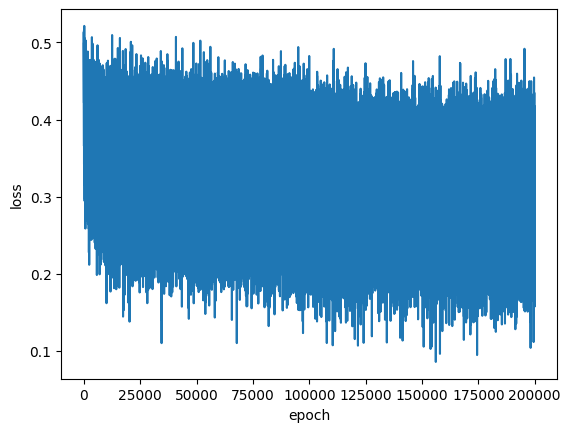

In [27]:
# plotting loss
plt.plot(loss_i)
plt.ylabel("loss");
plt.xlabel("epoch");

In [28]:
# assessing model performance
split_loss('train')
split_loss('val')

train 2.0385687351226807
val 2.09879732131958


#### normalizing a single W matrix at initialization is fine, but for deep networks, balancing them all is intractable. Therefore an alternative approach called **batch normalization** was developed, making deep learning possible ([Ioffe, Szegedy 2015]((https://arxiv.org/pdf/1502.03167)))
#### the premise is to normalize the preactivation $z$ of each hidden layer by normalizing the training batch during the forward pass
#### so $z = \gamma*\frac{z-\mu_\mathcal{B}}{\sigma_\mathcal{B}^2}+\beta$, where $\mu_\mathcal{B}$ and $\sigma_\mathcal{B}^2$ are the batch mean and variance and $\gamma$ and $\beta$ are learnable parameters 

In [29]:
# initialize the model with batch normalization

n_embedding = 10 # size of the embedding dimension
n_hidden = 200 # number of neurons in the hidden layer
g = torch.Generator().manual_seed(1994) # generator for reproducibility

C = torch.randn((vocab_size, n_embedding),            generator=g)
W1 = torch.randn((n_embedding*block_size, n_hidden),  generator=g) * kaiming  # kaiming normalization
#b1 = torch.randn(n_hidden,                            generator=g) # bias is redundant because bn_bias already handles it
W2 = torch.randn((n_hidden, vocab_size),              generator=g) * 0.01
b2 = torch.randn(vocab_size,                          generator=g) * 0

bn_gain = torch.ones(1,n_hidden)
bn_bias = torch.zeros(1,n_hidden)
bn_mean_running = torch.zeros(1,n_hidden) # see note below
bn_std_running = torch.ones(1,n_hidden) # see note below

parameters = [C, W1, W2, b2, bn_gain, bn_bias]

for p in parameters:
    p.requires_grad = True
    
print(f"number of parameters = {sum(p.nelement() for p in parameters)}")

number of parameters = 12097


In [30]:
# retrain the model with batch normalization
batch_size = 32
steps = 200000
loss_i = []

print(f"  epoch  loss")
for i in range(steps):
    # batch the training data to optimize
    ix = torch.randint(0, Xtrn.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtrn[ix], Ytrn[ix] # batch X, Y
    
    #   pass
    emb = C[Xb] # embed the input batch characters
    emb_cat = emb.view(emb.shape[0], -1) # concatenate embeddings
    z = emb_cat @ W1 #+ b1 # linear hidden layer
    bn_mean_i = z.mean(0,keepdim=True) # see note below
    bn_std_i = z.std(0,keepdim=True) # see note below
    z = bn_gain * ((z - bn_mean_i)/ bn_std_i) + bn_bias # batch normalization
    h = torch.tanh(z) # nonlinear hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    with torch.no_grad():
        bn_mean_running = 0.999*bn_mean_running + 0.001*bn_mean_i # see note below
        bn_std_running = 0.999*bn_std_running + 0.001*bn_std_i # see note below
        
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    lr = 0.1 if i < 100000 else 0.01 # temper learning rate with increasing epochs
    for p in parameters:
        p.data -= lr * p.grad

    # track statistics
    if i % 10000 == 0:
        print(f"{i:7d}: {loss:4f}")
    loss_i.append(loss.log10().item())

print(f"{i:7d}: {loss:4f}")

  epoch  loss
      0: 3.334403
  10000: 2.158345
  20000: 2.051924
  30000: 2.208290
  40000: 1.982142
  50000: 2.234979
  60000: 1.964661
  70000: 2.218785
  80000: 2.187203
  90000: 2.129059
 100000: 2.331697
 110000: 2.031111
 120000: 1.942592
 130000: 1.897389
 140000: 2.196758
 150000: 2.200483
 160000: 2.421835
 170000: 2.111947
 180000: 2.348291
 190000: 1.791397
 199999: 1.942902


##### a quirk of batch normalization is that the neural network now expects "batches" for forward passes. In use, a single input will be supplied. To accomodate this, the method authors suggested a one-time computation of $\mu$ and $\sigma^2$ for all training examples after training, and using these in forward pass computations. ML engineers preferred a two-birds-one-stone approach where running means for these values were calculated during training. I call them bn_mean_running and bn_std_running above
##### also, b1 becomes redundant since its job is taken over by $\beta$, and indeed its gradient is set to 0. removing bias tensors in layers feeding into a batch normalization layer is best practice

In [31]:
# reassess model performance
@torch.no_grad() # decorator which boosts efficiency by bypassing backpropagation circuitry
def split_loss(split):
    x,y = {
        'train': (Xtrn, Ytrn),
        'val':   (Xdev, Ydev),
        'test':  (Xtst, Ytst)
    }[split]
    emb = C[x]
    emb_cat = emb.view(emb.shape[0], -1)
    z = emb_cat @ W1 + b1
    z = bn_gain * bn_gain * ((z - bn_mean_running)/bn_std_running) + bn_bias # batch normalization
    h = torch.tanh(z)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1439216136932373
val 2.190774440765381


#### the adjustments actually have just a minor bearing, but this is only because the 1-layer MLP is very shallow
#### for deep networks, if these problems are not addresed training is impossible